# 🚀 Support Vector Machine (SVM) – Толық Шпаргалка

## 1. SVM дегеніміз не?
**Support Vector Machine (Тірек векторлары машинасы)** — бұл деректерді класстарға (топтарға) бөлу үшін ең оңтайлы шекараны (гипержазықтықты) табатын қуатты машиналық оқыту алгоритмі.

Оның басты мақсаты — тек шекара сызу емес, сол шекара мен ең жақын нүктелердің арасындағы **ең үлкен қашықтықты (маржаны)** табу.

---

## 2. Негізгі Ұғымдар (Геометриясы)

* **Гипержазықтық (Hyperplane):** Екі класты бөлетін шекара.
  * 2D кеңістікте — бұл қарапайым **түзу сызық**.
  * 3D кеңістікте — бұл **жазық тақта (лист картона)**.
* **Тірек векторлары (Support Vectors):** Шекараға ең жақын орналасқан нүктелер. Модель тек осы нүктелерге сүйенеді (басқа миллиондаған нүктелер оған маңызды емес). Егер осы нүктелерді алып тастасақ, шекараның орны өзгереді.
* **Маржа (Margin):** Шекара мен тірек векторлары арасындағы "бос аймақ". SVM осы маржаны барынша үлкейтуге (максимизация) тырысады.

---

## 3. Kernel Trick (Ядролық фокус) - Өлшемді ұлғайту

Көбінесе өмірдегі деректерді қарапайым түзу сызықпен бөлу мүмкін емес. Бұл кезде SVM деректерді **жоғарырақ өлшемге** көтереді.

1. **1D-дан 2D-ға өту:**
   * Нүктелер бір түзудің бойында араласып жатыр делік.
   * Формула: `Y = X^2`
   * Нәтиже: Точкалар парабола болып жоғары көтеріледі. Енді оларды көлденең сызықпен бөлуге болады.
2. **2D-дан 3D-ға өту:**
   * Қызыл нүктелер ортада, көк нүктелер оларды қоршап тұр.
   * Формула: `Z = X_1^2 + X_2^2`
   * Нәтиже: Деректер 3D кеңістікте "чаша" (параболоид) пішінін алады. Енді ортасынан тегіс жазықтықпен кесіп өтуге болады (2D-да бұл тамаша шеңбер болып көрінеді).

---

## 4. Негізгі Параметрлер (Hyperparameters)

Модельді баптаған кезде екі басты параметрмен жұмыс істейміз:

### 1. `C` параметрі (Қатаңдық / Soft Margin)
Шекараның қателіктерге қаншалықты төзімді екенін көрсетеді.
* **C үлкен болса:** Модель қателіктерді жек көреді. Граница өте қисық және күрделі болады (Overfitting қаупі).
* **C кіші болса:** Модель қателерге кешірімді. Бір-екі нүкте қате жаққа өтіп кетсе де, шекара тегіс әрі сенімді болады.

### 2. `gamma` параметрі (Ядро радиусы)
Тек `kernel='rbf'` қолданғанда жұмыс істейді. Бір нүктенің ықпал ету аймағын (радиусын) анықтайды.
* **gamma кіші (`auto`, `scale`):** Нүктенің ықпалы кең. Шекаралар тегіс, үлкен "материктер" пайда болады.
* **gamma үлкен:** Нүктенің ықпалы өте тар. Модель әрбір нүктенің айналасына жеке "оралған" шекара сызып тастайды (Overfitting қаупі).

---

## 5. Python-дағы (scikit-learn) Коды

Осы кодты Colab-тағы код ұяшығына қойып, модельдің қалай жұмыс істейтінін көре аласыз:

```python
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# 1. Деректерді дайындау (Крест және Кольцо)
class_0 = np.array([[0.0, 0.0], [1.0, 0.0], [-1.0, 0.0], [0.0, 1.0], [0.0, -1.0]])
class_1 = np.array([[3.0, 0.0], [-3.0, 0.0], [0.0, 3.0], [0.0, -3.0],
                    [2.0, 2.0], [-2.0, 2.0], [-2.0, -2.0], [2.0, -2.0]])

X = np.vstack((class_0, class_1))
y = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1])

# 2. SVM Модельді құру (RBF ядросы)
svm_model = SVC(kernel='rbf', C=1.0, gamma=0.5)
svm_model.fit(X, y)

# 3. Визуализация (Фонды бояу)
plt.figure(figsize=(7, 7))
plt.scatter(class_0[:, 0], class_0[:, 1], color='red', label='Класс 0', s=100)
plt.scatter(class_1[:, 0], class_1[:, 1], color='blue', label='Класс 1', s=100)

xx, yy = np.meshgrid(np.linspace(-4, 4, 500), np.linspace(-4, 4, 500))
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = svm_model.predict(grid_points).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.2, colors=['red', 'blue'], levels=[0, 0.5, 1])
plt.contour(xx, yy, Z, colors='k', levels=[0.5], linewidths=2)
plt.title("SVM арқылы бейсызықтық шекара (RBF)")
plt.legend()
plt.show()
```

---

## 6. Қайда қолданылады? (Нақты мысалдар)

* **Кескін сегментациясы:** Ғарыштан түсірілген спутник суреттерінен (satellite images) урбанизацияланған аймақтарды, ғимараттар мен жолдарды табиғаттан бөліп алу.
* **Медициналық диагноздар:** Мысалы, пациенттің көрсеткіштері бойынша аурудың бар/жоғын болжау.


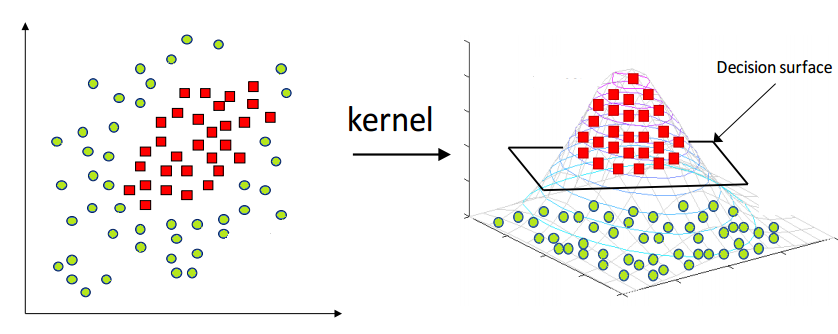

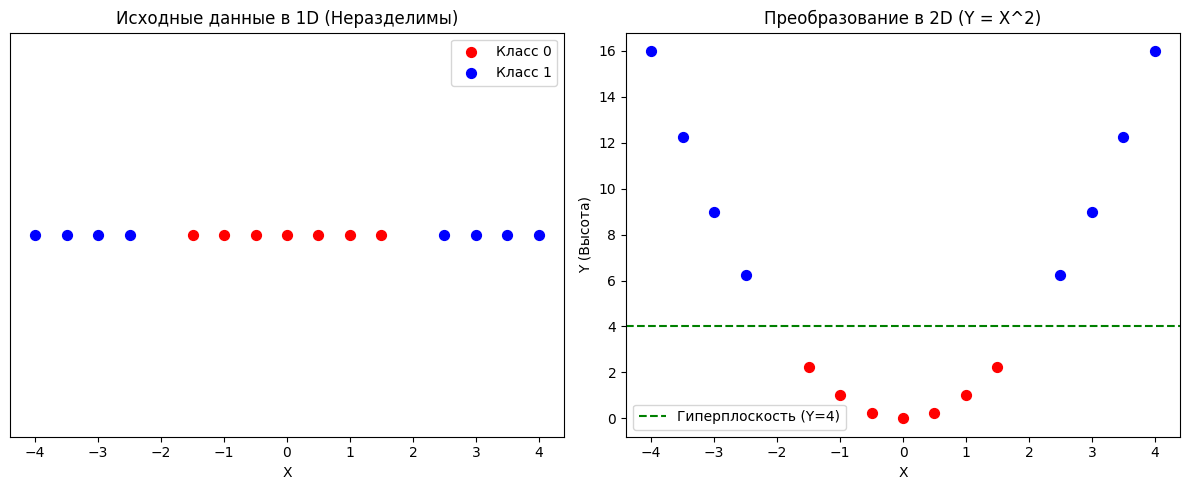

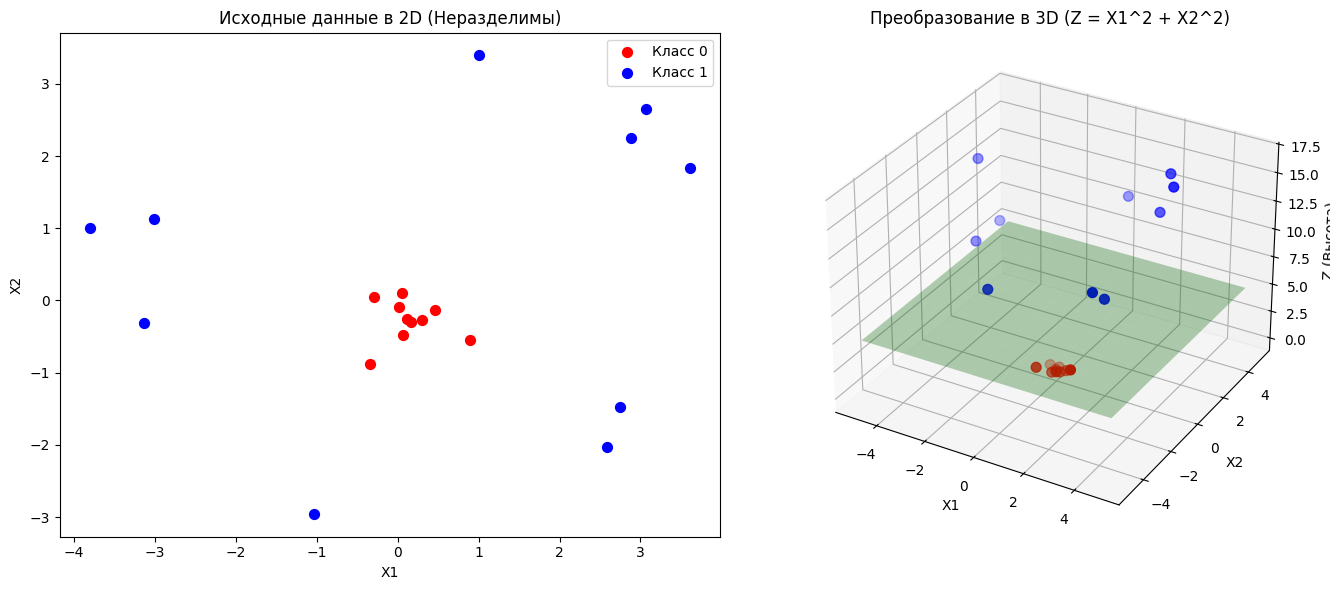

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# ДАТАСЕТ 1: Из 1D в 2D (Парабола)
# ==========================================
# Генерируем 15 точек на оси X
# Класс 0 (Красные) в центре от -1.5 до 1.5
X1_class0 = np.linspace(-1.5, 1.5, 7)
# Класс 1 (Синие) по краям
X1_class1 = np.concatenate([np.linspace(-4, -2.5, 4), np.linspace(2.5, 4, 4)])

# Преобразование в 2D (Y = X^2)
Y1_class0 = X1_class0**2
Y1_class1 = X1_class1**2

# Визуализация 1D -> 2D
fig1 = plt.figure(figsize=(12, 5))

# График ДО (1D)
ax1 = fig1.add_subplot(121)
ax1.scatter(X1_class0, np.zeros_like(X1_class0), color='red', label='Класс 0', s=50)
ax1.scatter(X1_class1, np.zeros_like(X1_class1), color='blue', label='Класс 1', s=50)
ax1.set_title("Исходные данные в 1D (Неразделимы)")
ax1.set_xlabel("X")
ax1.set_yticks([]) # Убираем ось Y, так как её тут по сути нет
ax1.legend()

# График ПОСЛЕ (2D)
ax2 = fig1.add_subplot(122)
ax2.scatter(X1_class0, Y1_class0, color='red', s=50)
ax2.scatter(X1_class1, Y1_class1, color='blue', s=50)
# Рисуем ту самую гиперплоскость (линию), которая их разделит
ax2.axhline(y=4, color='green', linestyle='--', label='Гиперплоскость (Y=4)')
ax2.set_title("Преобразование в 2D (Y = X^2)")
ax2.set_xlabel("X")
ax2.set_ylabel("Y (Высота)")
ax2.legend()

plt.tight_layout()
plt.show()

# ==========================================
# ДАТАСЕТ 2: Из 2D в 3D (Чаша)
# ==========================================


# Генерируем 20 точек (Круги)
# Класс 0 (Красные) в центре (радиус от 0 до 1.5)
r0 = np.random.uniform(0, 1.5, 10)
theta0 = np.random.uniform(0, 2*np.pi, 10)
X2_class0_x = r0 * np.cos(theta0)
X2_class0_y = r0 * np.sin(theta0)

# Класс 1 (Синие) снаружи (радиус от 3 до 4.5)
r1 = np.random.uniform(3, 4.5, 10)
theta1 = np.random.uniform(0, 2*np.pi, 10)
X2_class1_x = r1 * np.cos(theta1)
X2_class1_y = r1 * np.sin(theta1)

# Преобразование в 3D (Z = X^2 + Y^2)
Z_class0 = X2_class0_x**2 + X2_class0_y**2
Z_class1 = X2_class1_x**2 + X2_class1_y**2

# Визуализация 2D -> 3D
fig2 = plt.figure(figsize=(14, 6))

# График ДО (2D)
ax3 = fig2.add_subplot(121)
ax3.scatter(X2_class0_x, X2_class0_y, color='red', label='Класс 0', s=50)
ax3.scatter(X2_class1_x, X2_class1_y, color='blue', label='Класс 1', s=50)
ax3.set_title("Исходные данные в 2D (Неразделимы)")
ax3.set_xlabel("X1")
ax3.set_ylabel("X2")
ax3.legend()

# График ПОСЛЕ (3D)
ax4 = fig2.add_subplot(122, projection='3d')
ax4.scatter(X2_class0_x, X2_class0_y, Z_class0, color='red', s=50)
ax4.scatter(X2_class1_x, X2_class1_y, Z_class1, color='blue', s=50)

# Рисуем разделяющую гиперплоскость (лист картона в 3D)
# Создаем сетку для плоскости
xx, yy = np.meshgrid(np.linspace(-5, 5, 10), np.linspace(-5, 5, 10))
zz = np.full_like(xx, 5) # Плоскость лежит на высоте Z=5
ax4.plot_surface(xx, yy, zz, alpha=0.3, color='green')

ax4.set_title("Преобразование в 3D (Z = X1^2 + X2^2)")
ax4.set_xlabel("X1")
ax4.set_ylabel("X2")
ax4.set_zlabel("Z (Высота)")

plt.tight_layout()
plt.show()

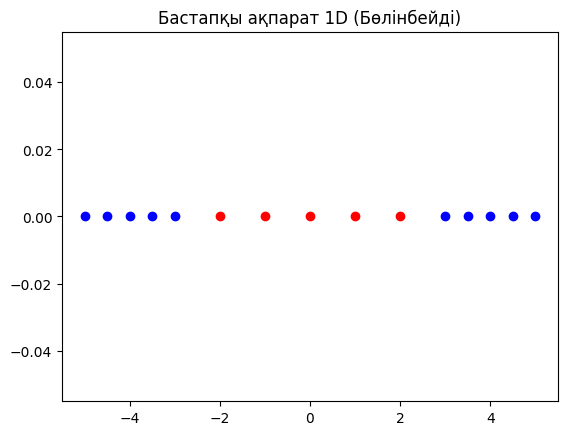

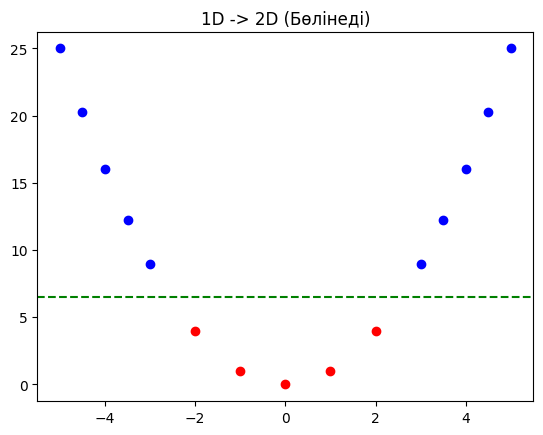

In [ ]:
# 1D
# Класс - 1
x_0 = np.linspace(-2, 2, 5)
x_1 = np.concat([np.linspace(-5, -3, 5), np.linspace(3, 5, 5)])

plt.scatter(x_0, np.zeros_like(x_0), color='red', label='Класс 0')
plt.scatter(x_1, np.zeros_like(x_1), color='blue', label='Класс 1')
plt.title("Бастапқы ақпарат 1D (Бөлінбейді)")
plt.show()

y_0 = x_0 ** 2
y_1 = x_1 ** 2

plt.scatter(x_0, y_0, color='red', label='Класс 0')
plt.scatter(x_1, y_1, color='blue', label='Класс 1')
plt.axhline(y=6.5, color='green', linestyle='--', label='Гиперплоскость (Y=4)')
plt.title("1D -> 2D (Бөлінеді)")
plt.show()

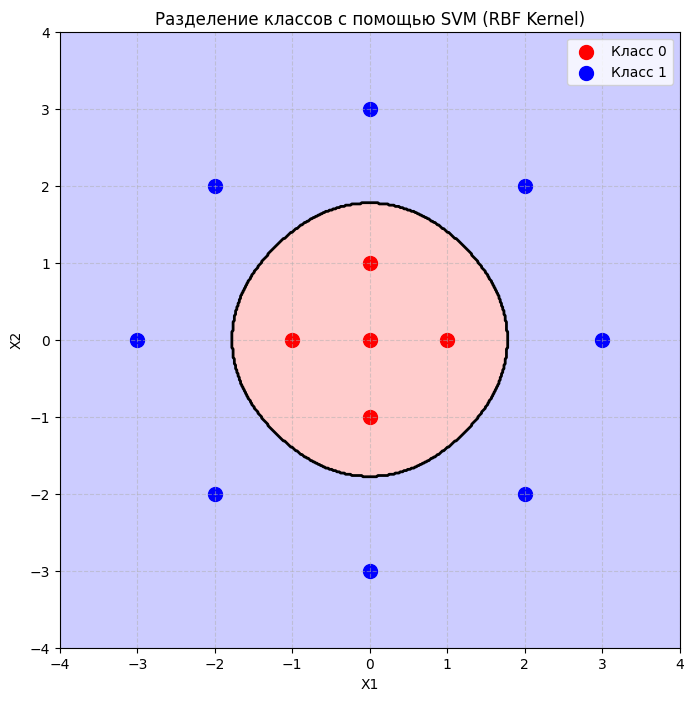

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# 1. НАШИ ДАННЫЕ (Те самые статические массивы)
class_0 = np.array([[0.0, 0.0], [1.0, 0.0], [-1.0, 0.0], [0.0, 1.0], [0.0, -1.0]])
class_1 = np.array([[3.0, 0.0], [-3.0, 0.0], [0.0, 3.0], [0.0, -3.0],
                    [2.0, 2.0], [-2.0, 2.0], [-2.0, -2.0], [2.0, -2.0]])

# Объединяем точки (X) и создаем метки классов (y)
X = np.vstack((class_0, class_1))
y = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1])

# 2. СОЗДАНИЕ И ОБУЧЕНИЕ МОДЕЛИ SVM
# Выбираем ядро RBF, настраиваем параметры C и gamma
svm_model = SVC(kernel='rbf', C=1.0, gamma=0.5)

# Обучаем модель находить границу
svm_model.fit(X, y)

# 3. ВИЗУАЛИЗАЦИЯ (Рисуем границу)
plt.figure(figsize=(8, 8))

# Рисуем наши исходные точки
plt.scatter(class_0[:, 0], class_0[:, 1], color='red', label='Класс 0', s=100)
plt.scatter(class_1[:, 0], class_1[:, 1], color='blue', label='Класс 1', s=100)

# Магия отрисовки границы (создаем сетку пикселей на фоне)
xx, yy = np.meshgrid(np.linspace(-4, 4, 500), np.linspace(-4, 4, 500))
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Просим модель предсказать класс для каждого пикселя фона
Z = svm_model.predict(grid_points)
Z = Z.reshape(xx.shape)

# Закрашиваем фон в зависимости от предсказания
plt.contourf(xx, yy, Z, alpha=0.2, colors=['red', 'blue'], levels=[0, 0.5, 1])
# Рисуем саму четкую линию границы
plt.contour(xx, yy, Z, colors='k', levels=[0.5], linewidths=2)

plt.title("Разделение классов с помощью SVM (RBF Kernel)")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Проект

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("/content/data.csv")
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

Маңызды екі бағанды таңдап, сол бойынша svm жұмысына қарапайым зерттеу жасаймын

In [4]:
df = data[['diagnosis', 'radius_mean', 'texture_mean']]
df.head()

,diagnosis,radius_mean,texture_mean
0,M,17.99,10.38
1,M,20.57,17.77
2,M,19.69,21.25
3,M,11.42,20.38
4,M,20.29,14.34


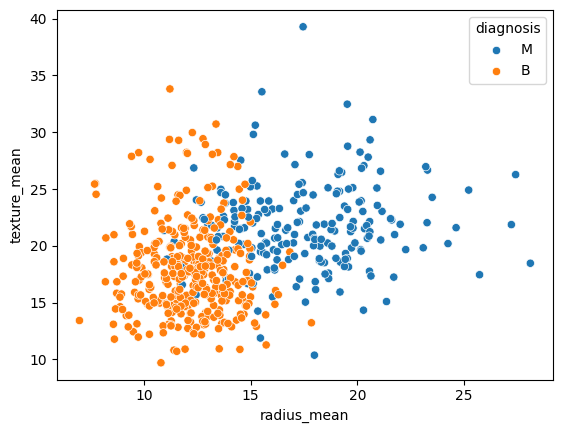

In [5]:
sns.scatterplot(data=df, x='radius_mean', y='texture_mean', hue='diagnosis')
plt.show()

In [6]:
df['rad_tex'] = df['radius_mean'] ** 2 + df['texture_mean'] ** 2
df.head()

/tmp/ipykernel_223/454541422.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['rad_tex'] = df['radius_mean'] ** 2 + df['texture_mean'] ** 2


,diagnosis,radius_mean,texture_mean,rad_tex
0,M,17.99,10.38,431.3845
1,M,20.57,17.77,738.8978
2,M,19.69,21.25,839.2586
3,M,11.42,20.38,545.7608
4,M,20.29,14.34,617.3197


In [7]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df['diagnosis'] = encoder.fit_transform(df['diagnosis'])
df.head()

/tmp/ipykernel_223/2329584696.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['diagnosis'] = encoder.fit_transform(df['diagnosis'])


,diagnosis,radius_mean,texture_mean,rad_tex
0,1,17.99,10.38,431.3845
1,1,20.57,17.77,738.8978
2,1,19.69,21.25,839.2586
3,1,11.42,20.38,545.7608
4,1,20.29,14.34,617.3197


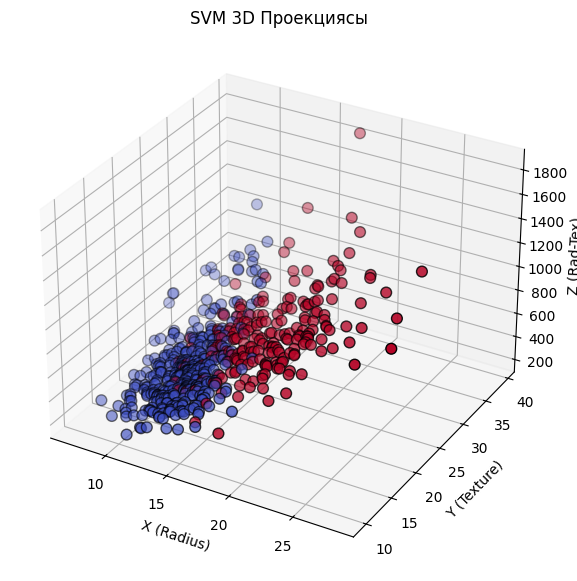

In [8]:
# 1. 3D ортаны дайындау
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d') # Мына жерде '3d' болуы міндетті

# 2. Деректерді салу (X, Y, Z)
# x_coords, y_coords, z_coords - сіздің массивтеріңіз
ax.scatter(df['radius_mean'], df['texture_mean'], df['rad_tex'], c=df['diagnosis'], cmap='coolwarm', s=60, edgecolors='k')

# 3. Атауларын жазу
ax.set_xlabel('X (Radius)')
ax.set_ylabel('Y (Texture)')
ax.set_zlabel('Z (Rad-Tex)')
ax.set_title('SVM 3D Проекциясы')

plt.show()

In [32]:
x_c = np.random.random_integers(-100, 100, 200)
y_c = np.random.random_integers(-100, 100, 200)

circle = pd.DataFrame({"X": x_c, "Y": y_c})
circle['in3'] = np.where((circle['X']**2 + circle['Y']**2 <= 75 ** 2), 1, 0)
circle

/tmp/ipykernel_223/1209296285.py:1: DeprecationWarning: This function is deprecated. Please call randint(-100, 100 + 1) instead
  x_c = np.random.random_integers(-100, 100, 200)
/tmp/ipykernel_223/1209296285.py:2: DeprecationWarning: This function is deprecated. Please call randint(-100, 100 + 1) instead
  y_c = np.random.random_integers(-100, 100, 200)


,X,Y,in3
0,71,-30,0
1,40,56,1
2,68,88,0
3,10,-23,1
4,-34,-89,0
...,...,...,...
195,-97,-51,0
196,-93,-71,0
197,-47,-95,0
198,45,56,1


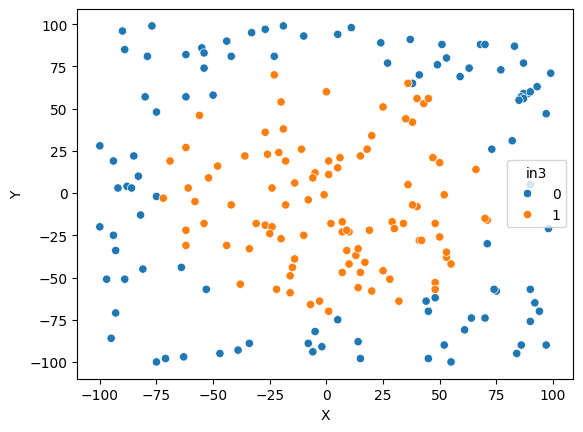

In [33]:
sns.scatterplot(data=circle, x='X', y='Y', hue='in3')
plt.show()

In [34]:
circle['Z'] = circle['X'] ** 2 + circle['Y'] ** 2
circle

,X,Y,in3,Z
0,71,-30,0,5941
1,40,56,1,4736
2,68,88,0,12368
3,10,-23,1,629
4,-34,-89,0,9077
...,...,...,...,...
195,-97,-51,0,12010
196,-93,-71,0,13690
197,-47,-95,0,11234
198,45,56,1,5161


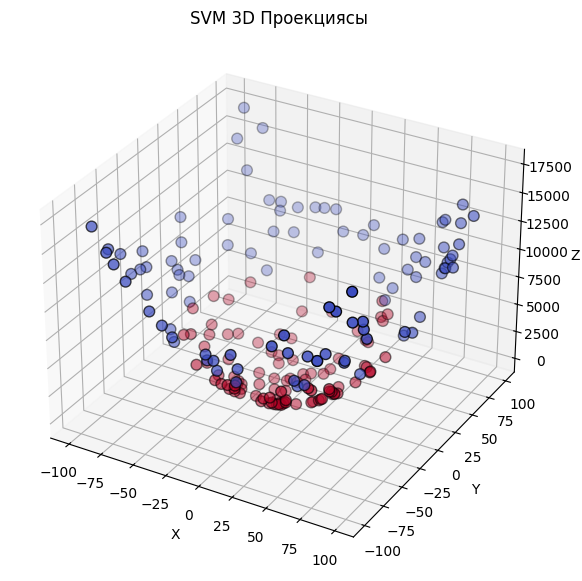

In [35]:
# 1. 3D ортаны дайындау
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d') # Мына жерде '3d' болуы міндетті

# 2. Деректерді салу (X, Y, Z)
# x_coords, y_coords, z_coords - сіздің массивтеріңіз
ax.scatter(circle["X"], circle['Y'], circle['Z'], c=circle['in3'], cmap='coolwarm', s=60, edgecolors='k')

# 3. Атауларын жазу
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('SVM 3D Проекциясы')

plt.show()

In [41]:
from sklearn.model_selection import train_test_split

In [42]:
from sklearn.svm import SVC

X, y = circle[['X', 'Y']], circle['in3']

c_model = SVC(kernel='rbf', C=1.0, gamma=0.5)
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
c_model.fit(x_train, y_train)



SVC(gamma=0.5)

In [43]:
y_pred = c_model.predict(x_test)
